In [1]:
import pandas as pd
import matplotlib.pyplot as plt


In [2]:
data = pd.read_csv("ngo_disbursements_v3.csv")

In [4]:
data

,transaction_id,ngo_id,amount,days_since_donation,ngo_avg_verification_time,ngo_pending_ratio,is_round_number,hour_of_day,is_anomalous,reason
0,T00001,NGO001,14345.85,5.30,50.40,0.29,False,11,0,NaN
1,T00002,NGO001,21991.43,4.29,42.89,0.19,False,15,0,NaN
2,T00003,NGO001,9348.24,6.94,42.93,0.23,False,17,0,NaN
3,T00004,NGO001,14412.09,13.68,46.84,0.27,False,11,0,NaN
4,T00005,NGO001,11726.99,5.12,43.85,0.33,False,12,0,NaN
...,...,...,...,...,...,...,...,...,...,...
4522,T04523,NGO020,11585.71,8.52,35.11,0.20,False,17,0,NaN
4523,T04524,NGO020,9429.66,1.27,33.57,0.15,False,8,0,NaN
4524,T04525,NGO020,15972.18,5.09,35.58,0.21,False,11,0,NaN
4525,T04526,NGO020,11125.74,6.49,38.84,0.25,False,20,0,NaN


In [5]:
labels = data[['transaction_id', 'ngo_id', 'is_anomalous', 'reason']].copy()
data = data.drop(columns=['transaction_id', 'ngo_id', 'is_anomalous', 'reason'])

In [6]:
print(data.shape)

(4527, 6)


In [7]:
print(data.dtypes)

amount                       float64
days_since_donation          float64
ngo_avg_verification_time    float64
ngo_pending_ratio            float64
is_round_number                 bool
hour_of_day                    int64
dtype: object


In [8]:
data['is_round_number'] = data['is_round_number'].astype(int)

In [9]:
print(data.dtypes)

amount                       float64
days_since_donation          float64
ngo_avg_verification_time    float64
ngo_pending_ratio            float64
is_round_number                int64
hour_of_day                    int64
dtype: object


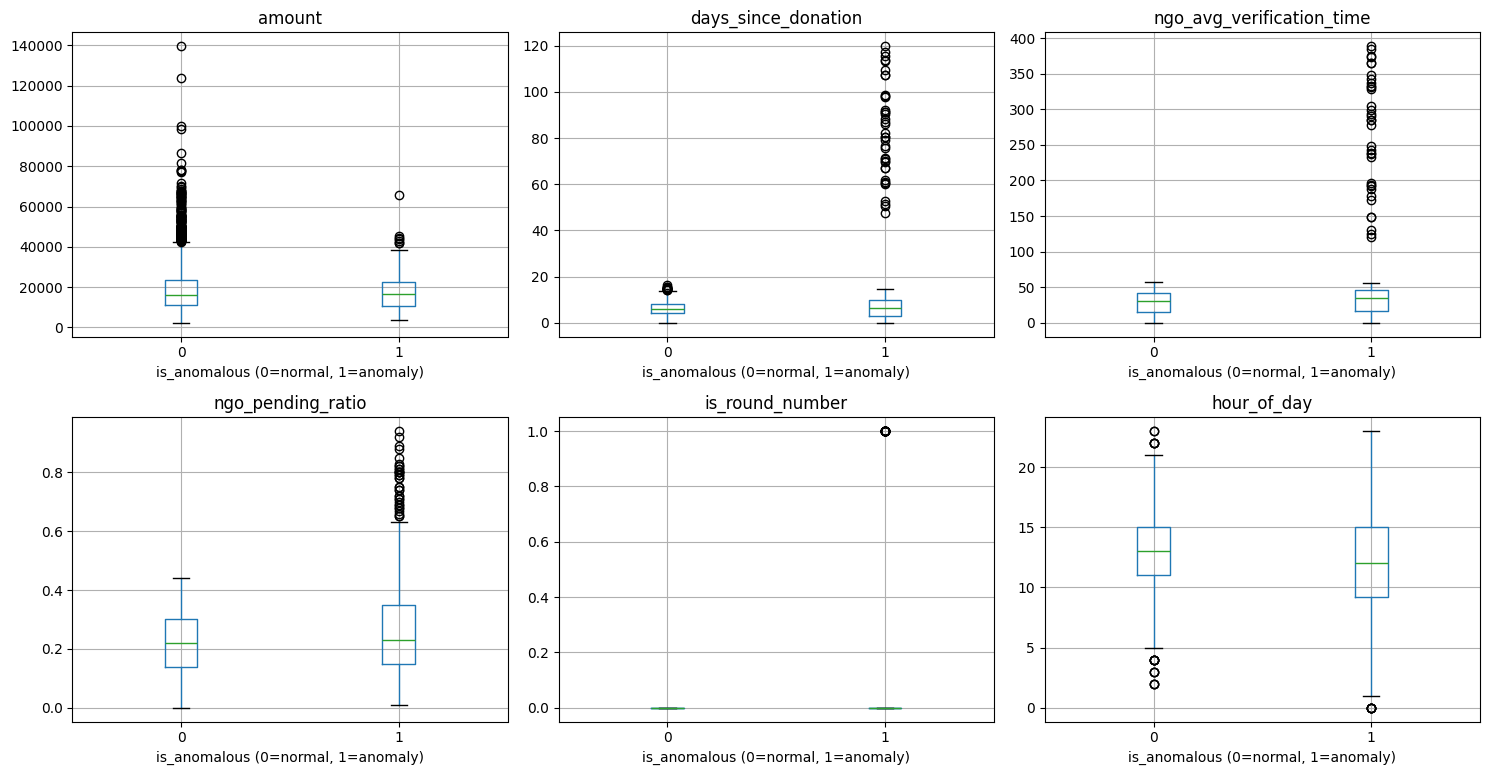

In [10]:
viz = data.copy()
viz['is_anomalous'] = labels['is_anomalous']

features = ['amount', 'days_since_donation', 'ngo_avg_verification_time',
            'ngo_pending_ratio', 'is_round_number', 'hour_of_day']

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for i, col in enumerate(features):
    viz.boxplot(column=col, by='is_anomalous', ax=axes[i])
    axes[i].set_title(col)
    axes[i].set_xlabel('is_anomalous (0=normal, 1=anomaly)')

plt.suptitle('')
plt.tight_layout()
plt.savefig('feature_distributions.png', dpi=100)
plt.show()

In [13]:
pd.crosstab(labels['is_anomalous'], data['is_round_number'], normalize='index')

is_round_number,0,1
is_anomalous,,
0,1.000000,0.000000
1,0.846535,0.153465


In [14]:
from sklearn.ensemble import IsolationForest

model = IsolationForest(
    n_estimators=200,
    contamination=0.045,   # matches our injected ~4.5% anomaly rate
    random_state=42
)

model.fit(data)

,"n_estimators n_estimators: int, default=100The number of base estimators in the ensemble.",200
,"max_samples max_samples: ""auto"", int or float, default=""auto""The number of samples to draw from X to train each base estimator.- If int, then draw `max_samples` samples.- If float, then draw `max_samples * X.shape[0]` samples.- If ""auto"", then `max_samples=min(256, n_samples)`.If max_samples is larger than the number of samples provided,all samples will be used for all trees (no sampling).",'auto'
,"contamination contamination: 'auto' or float, default='auto'The amount of contamination of the data set, i.e. the proportionof outliers in the data set. Used when fitting to define the thresholdon the scores of the samples.- If 'auto', the threshold is determined as in the original paper.- If float, the contamination should be in the range (0, 0.5]... versionchanged:: 0.22 The default value of ``contamination`` changed from 0.1 to ``'auto'``.",0.045
,"max_features max_features: int or float, default=1.0The number of features to draw from X to train each base estimator.- If int, then draw `max_features` features.- If float, then draw `max(1, int(max_features * n_features_in_))` features.Note: using a float number less than 1.0 or integer less than number offeatures will enable feature subsampling and leads to a longer runtime.",1.0
,"bootstrap bootstrap: bool, default=FalseIf True, individual trees are fit on random subsets of the trainingdata sampled with replacement. If False, sampling without replacementis performed.",False
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel for :meth:`fit`. ``None`` means 1unless in a :obj:`joblib.parallel_backend` context. ``-1`` means usingall processors. See :term:`Glossary ` for more details.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the pseudo-randomness of the selection of the featureand split values for each branching step and each tree in the forest.Pass an int for reproducible results across multiple function calls.See :term:`Glossary `.",42
,"verbose verbose: int, default=0Controls the verbosity of the tree building process.",0
,"warm_start warm_start: bool, default=FalseWhen set to ``True``, reuse the solution of the previous call to fitand add more estimators to the ensemble, otherwise, just fit a wholenew forest. See :term:`the Glossary `... versionadded:: 0.21",False


In [15]:
data['anomaly_score'] = model.decision_function(data[
    ['amount','days_since_donation','ngo_avg_verification_time',
     'ngo_pending_ratio','is_round_number','hour_of_day']
])
data['predicted_anomaly'] = model.predict(data[
    ['amount','days_since_donation','ngo_avg_verification_time',
     'ngo_pending_ratio','is_round_number','hour_of_day']
])  # -1 = anomaly, 1 = normal

# rejoin ground truth by index for comparison
results = data.copy()
results['actual_anomaly'] = labels['is_anomalous']

from sklearn.metrics import classification_report
# convert predicted_anomaly (-1/1) to same format as actual (1/0)
results['predicted_anomaly_binary'] = (results['predicted_anomaly'] == -1).astype(int)

print(classification_report(results['actual_anomaly'], results['predicted_anomaly_binary']))

              precision    recall  f1-score   support

           0       0.98      0.98      0.98      4325
           1       0.66      0.67      0.67       202

    accuracy                           0.97      4527
   macro avg       0.82      0.83      0.82      4527
weighted avg       0.97      0.97      0.97      4527



In [16]:
from sklearn.metrics import f1_score, precision_score, recall_score

feature_cols = ['amount','days_since_donation','ngo_avg_verification_time',
                 'ngo_pending_ratio','is_round_number','hour_of_day']

for c in [0.03, 0.045, 0.06, 0.08, 0.10]:
    m = IsolationForest(n_estimators=200, contamination=c, random_state=42)
    m.fit(data[feature_cols])
    pred = (m.predict(data[feature_cols]) == -1).astype(int)
    actual = labels['is_anomalous']
    print(f"contamination={c}: precision={precision_score(actual,pred):.2f}, "
          f"recall={recall_score(actual,pred):.2f}, f1={f1_score(actual,pred):.2f}")

contamination=0.03: precision=0.76, recall=0.51, f1=0.62
contamination=0.045: precision=0.66, recall=0.67, f1=0.67
contamination=0.06: precision=0.57, recall=0.77, f1=0.66
contamination=0.08: precision=0.48, recall=0.86, f1=0.62
contamination=0.1: precision=0.40, recall=0.91, f1=0.56


In [17]:
def generate_reason(row):
    reasons = []
    
    if row['days_since_donation'] > 30:
        reasons.append(("days_since_donation", f"Donation sat unspent for {row['days_since_donation']:.0f} days"))
    if row['days_since_donation'] < 0.5:
        reasons.append(("days_since_donation", "Disbursed within hours of donation arriving"))
    if row['ngo_pending_ratio'] > 0.5:
        reasons.append(("ngo_pending_ratio", f"NGO has high pending/unverified ratio ({row['ngo_pending_ratio']:.0%})"))
    if row['is_round_number'] == 1:
        reasons.append(("is_round_number", "Round-number amount, possible structuring"))
    if row['hour_of_day'] < 5 or row['hour_of_day'] > 22:
        reasons.append(("hour_of_day", f"Disbursement created at unusual hour ({row['hour_of_day']}:00)"))
    
    if not reasons:
        return "Flagged by model — no single dominant factor identified"
    
    # just take the first triggered rule (or you could rank by severity later)
    return reasons[0][1]

In [18]:
import joblib

# retrain final model with chosen contamination
final_model = IsolationForest(n_estimators=200, contamination=0.045, random_state=42)
final_model.fit(data[feature_cols])

joblib.dump(final_model, "isolation_forest_model.pkl")

['isolation_forest_model.pkl']